In [2]:
import copy
from copy import deepcopy

import matplotlib as mpl
import matplotlib.pyplot as plt  # For plotting results; optional
import numpy as np

from landlab import RasterModelGrid  # Grid utility
from landlab import imshow_grid, imshowhs_grid  # For plotting results; optional
from landlab.components import BedrockLandslider  # BedrockLandslider model
from landlab.components import SpaceLargeScaleEroder  # SPACE model
from landlab.components import PriorityFloodFlowRouter

In [12]:
# Set grid parameters
num_rows = 50
num_columns = 50
node_spacing = 25.0

# track sediment flux at the node adjacent to the outlet at lower-left
node_next_to_outlet = num_columns + 1

# Instantiate model grid
mg = RasterModelGrid((num_rows, num_columns), node_spacing)
# add field ’topographic elevation’ to the grid
mg.add_zeros("topographic__elevation", at="node")
# set constant random seed for consistent topographic roughness
np.random.seed(seed=5000)

# Create initial model topography:

# add topographic roughness
random_noise = (
    np.random.rand(len(mg.node_y)) / 1000.0
)  # impose topography values on model grid
mg["node"]["topographic__elevation"] += random_noise

# add field 'soil__depth' to the grid
mg.add_zeros("soil__depth", at="node")

# Set 2 m of initial soil depth at core nodes
mg.at_node["soil__depth"][mg.core_nodes] = 1.0  # meters

# Add field 'bedrock__elevation' to the grid
mg.add_zeros("bedrock__elevation", at="node")

# Sum 'soil__depth' and 'bedrock__elevation'
# to yield 'topographic elevation'
mg.at_node["bedrock__elevation"][:] = mg.at_node["topographic__elevation"]
mg.at_node["topographic__elevation"][:] += mg.at_node["soil__depth"]

[0.00022905 0.00036067 0.00072765 ... 0.0009678  0.00086973 0.00043516]


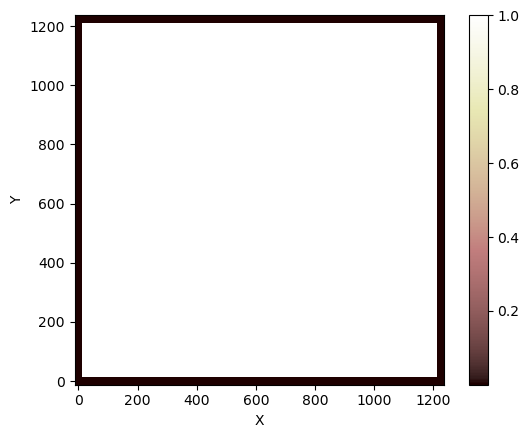

In [15]:
# create deep(?) copy of original topography
initialtopography = mg.at_node["topographic__elevation"].copy()

#Landlab automatically reshapes to 1D array
print(initialtopography)
imshow_grid(mg, initialtopography)

In [5]:
# Open all model boundary edges
mg.set_closed_boundaries_at_grid_edges(
    bottom_is_closed=False,
    left_is_closed=False,
    right_is_closed=False,
    top_is_closed=False,
)

In [6]:
# Instantiate flow router
fr = PriorityFloodFlowRouter(mg, flow_metric="D8", suppress_out=True)

# Instantiate SPACE model with chosen parameters
sp = SpaceLargeScaleEroder(
    mg,
    K_sed=2.5e-5,
    K_br=2.5e-5,
    F_f=0.0,
    phi=0.0,
    H_star=1.0,
    v_s=1,
    m_sp=0.5,
    n_sp=1.0,
    sp_crit_sed=0,
    sp_crit_br=0,
)

/opt/tljh/user/envs/csdms/lib/python3.13/site-packages/richdem/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


0.20 of model run completed


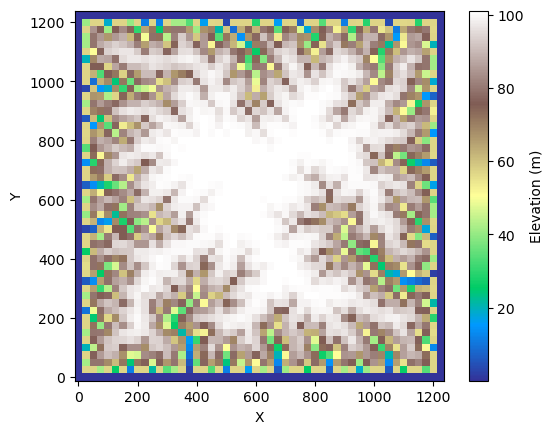

0.40 of model run completed


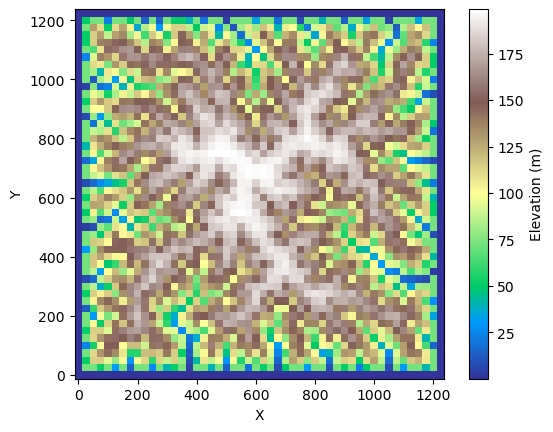

0.60 of model run completed


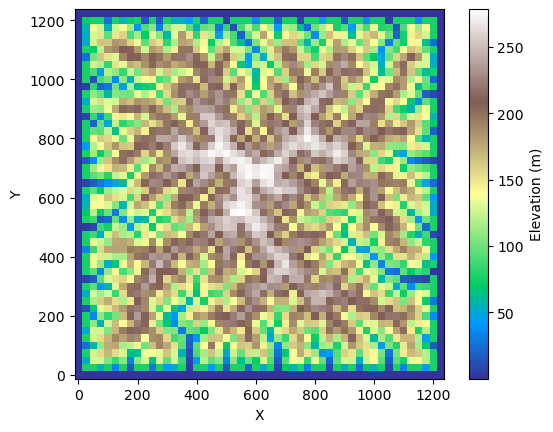

0.80 of model run completed


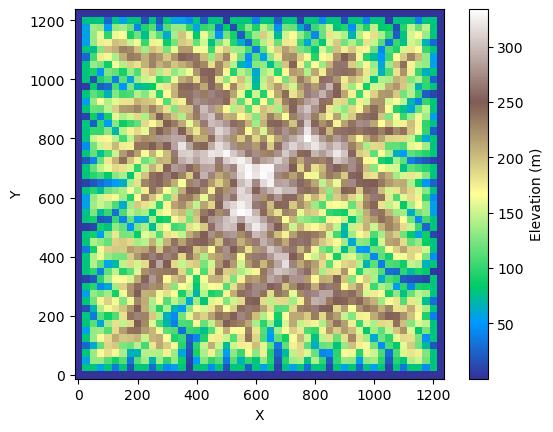

1.00 of model run completed


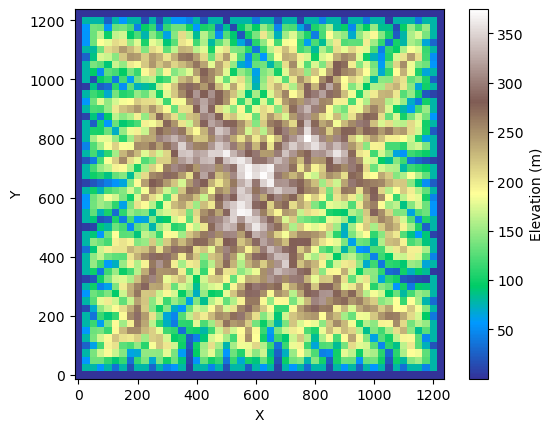

In [7]:
# Set model timestep
timestep = 1e3  # years

# Set elapsed time to zero
elapsed_time = 0.0  # years

# Set timestep count to zero
count = 0

# Set model run time
run_time = 5e5  # years

# Array to save sediment flux values
sed_flux = np.zeros(int(run_time // timestep))

# Uplift rate in m/yr
U = 1e-3

cmap = copy.copy(mpl.colormaps["terrain"])

while elapsed_time < run_time:  # time units of years
    # Insert uplift at core nodes
    mg.at_node["bedrock__elevation"][mg.core_nodes] += U * timestep
    mg.at_node["topographic__elevation"][:] = (
        mg.at_node["bedrock__elevation"] + mg.at_node["soil__depth"]
    )

    # Run the flow router
    fr.run_one_step()

    # Run SPACE for one time step
    sp.run_one_step(dt=timestep)

    # Add to value of elapsed time
    elapsed_time += timestep

    if np.mod(elapsed_time, 1e5) == 0:
        print("%.2f of model run completed" % (elapsed_time / run_time))
        imshow_grid(
            mg, "topographic__elevation", cmap=cmap, colorbar_label="Elevation (m)"
        )
        plt.show()

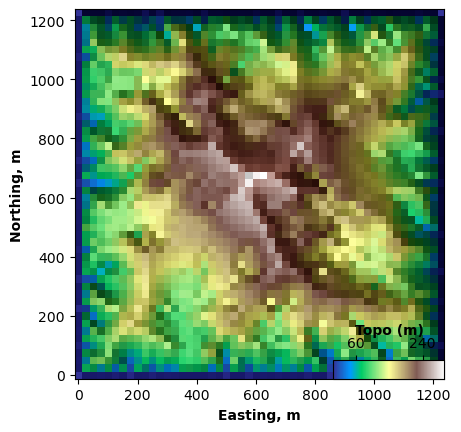

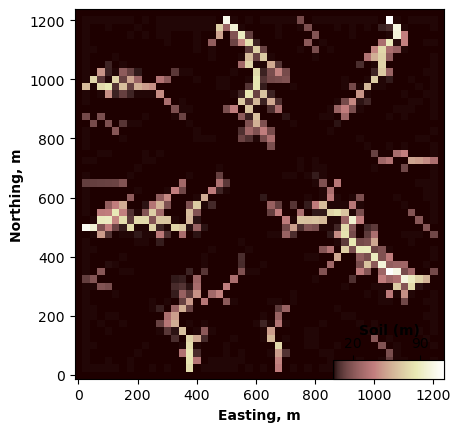

In [23]:
cmap = copy.copy(mpl.colormaps["terrain"])
# Show DEM draped over the shaded topographic relief
imshowhs_grid(
    mg,
    "topographic__elevation",
    var_name="Topo",
    var_units=r"m",
    grid_units=("m", "m"),
    cmap=cmap,
    ticks_km=False,
)
plt.show()
# Show Soil thickness draped over the shaded topographic relief
cmap = copy.copy(mpl.colormaps["pink"])
imshowhs_grid(
    mg,
    "topographic__elevation",
    drape1=mg.at_node["soil__depth"],
    plot_type="Drape1",
    var_name="Soil",
    var_units=r"m",
    grid_units=("m", "m"),
    cmap=cmap,
    ticks_km=False,
)

z_before_LS = np.array(mg["node"]["topographic__elevation"])

In [7]:
# Instantiate flow router, with additional multiple flow director for hillslopes
fr = PriorityFloodFlowRouter(
    mg,
    flow_metric="D8",
    separate_hill_flow=True,
    hill_flow_metric="Quinn",
    update_hill_flow_instantaneous=True,
)

# Instantiate SPACE model with chosen parameters
hy = BedrockLandslider(
    mg,
    angle_int_frict=0.4,
    cohesion_eff=1e3,
    landslides_return_time=1000,
    landslides_on_boundary_nodes=False,
)

In [24]:
# Reset elevation back to elevation simulated without landslides to test various landslide configuration settings

mg["node"]["topographic__elevation"][:] = z_before_LS
timestep = 20  # years
landslides_size_all_steps = []

for i in range(10):
    # Insert uplift at core nodes
    mg.at_node["bedrock__elevation"][mg.core_nodes] += U * timestep
    mg.at_node["topographic__elevation"][:] = (
        mg.at_node["bedrock__elevation"] + mg.at_node["soil__depth"]
    )

    # Run the flow router
    fr.run_one_step()

    # Run SPACE for one time step
    sp.run_one_step(dt=timestep)

    # Run BedrockLandslider for one time step
    hy.run_one_step(dt=timestep)

    # Store landslide sizes of current time step into general ls_size list
    landslides_size_all_steps = np.append(landslides_size_all_steps, hy.landslides_size)

[ 2. 32. 57. 16.  8.  3.  4. 22. 13.  7.  3. 24. 28. 46.  2. 18.  2.  6.
 96. 30.  5.  1. 10.  6.  4. 15. 20.  3.  8.  5. 15.  5.  7.  7.  3.  6.
 11.  6. 34. 18.  8.  1. 20. 12. 10.  5.  5.  3.  4.  3.  2.  2. 21.  3.
  2. 10.  5.  3. 15.  2. 15.  2.  2.  3.  5. 26.  1. 12. 31.  4. 48. 17.
  3.  4. 32. 12.  4.  5.  5. 15.  8. 13. 36.  9.  3.  1. 40.  5. 11.  9.
  4.  8.  1. 12. 34. 12.  7.  3.  1. 17. 38.  3.  9. 38. 15.  6.  9. 13.
 33.  8.  2.  8. 12.  5.  3.  1.  6.  3.  2. 12.  2. 14.  5.  1.  1. 15.
  5.  6.  7.  1.  6.  5.  9.  3.  2.  6.  2. 69.  6.  4.  3.  4.  1.  2.
 11.  4.  4.  1. 10.  5. 11.  1.  3. 10. 25.  1.  2.  5.  4. 28.  5.  3.
 54. 22. 34.  6.  6.  4.  7. 14.  2.  4. 11. 17.  2.  1.  5.  1.  5.  3.
  1. 29.  9.  5. 14.  3.  1.  2. 43. 15.  2.  4.  5.  2.  7.  4.  1.  1.
 13.  3.  2.  6. 71.  2.  2. 13. 10. 12.  4.  5.  3.  3.  5.  8.  3. 16.
  5.  9.  3. 13. 11.  2.  1. 12. 11.  8.  2.  7. 10. 10.  4.  1.  4. 12.
 10. 18.  5. 10. 10.  8. 39.  2.  3. 11.  4.  6.  3

Text(0, 0.5, 'Landslide frequency')

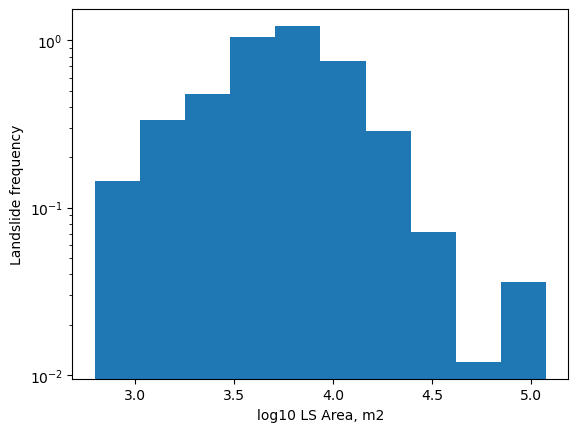

In [9]:
LS_size = landslides_size_all_steps * mg.dx**2
counts, bins = np.histogram(np.log10(LS_size), 10)
plt.hist(np.log10(LS_size), log=True, bins=bins, density=True)
plt.xlabel("log10 LS Area, m2")
plt.ylabel("Landslide frequency")

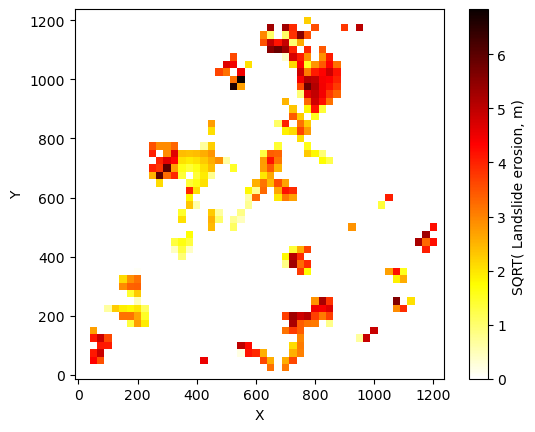

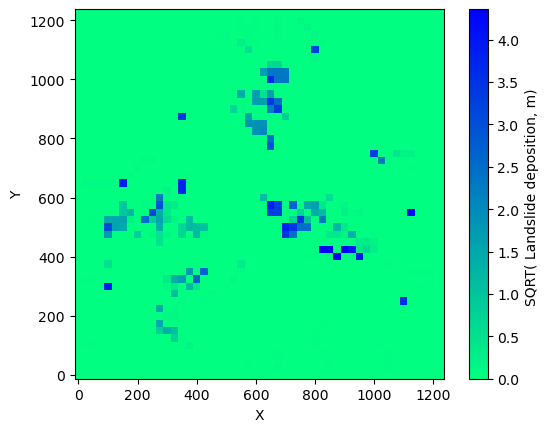

In [10]:
# Landslide Erosion
cmap = copy.copy(mpl.colormaps["hot_r"])
imshow_grid(
    mg,
    np.sqrt(mg.at_node["landslide__erosion"]),
    colorbar_label="SQRT( Landslide erosion, m) ",
    cmap=cmap,
)
plt.show()

# Landslide Deposition
cmap = copy.copy(mpl.colormaps["winter_r"])
imshow_grid(
    mg,
    np.sqrt(mg.at_node["landslide__deposition"]),
    colorbar_label="SQRT( Landslide deposition, m) ",
    cmap=cmap,
)
plt.show()

In [11]:
updatedtopography = mg.at_node["bedrock__elevation"]
topo_elev = mg.at_node["topographic__elevation"] 

In [17]:
# Show DEM draped over the ORIGINAL shaded topographic relief
imshowhs_grid(initialtopography, cmap="viridis")
plt.show()

# Show DEM draped over the UPDATED shaded topographic relief
imshowhs_grid(
    mg,
    "topographic__elevation",
    var_name="Topo",
    var_units=r"m",
    grid_units=("m", "m"),
    cmap=cmap,
    ticks_km=False,
)
plt.show()

TypeError: imshowhs_grid() missing 1 required positional argument: 'values'

In [19]:
print(initialtopography.dtype)

float64


In [22]:
initialtopo2D = np.reshape(initialtopography, grid.shape)
print(initialtopography)
print(np.shape(initialtopography))
imshowhs_grid(initialtopography, cmap="viridis")
plt.show()

[0.00022905 0.00036067 0.00072765 ... 0.0009678  0.00086973 0.00043516]
(2500,)


TypeError: imshowhs_grid() missing 1 required positional argument: 'values'

In [30]:
initialtopo2D = np.reshape(initialtopography, mg.shape)
print(initialtopo2D)

[[2.29047865e-04 3.60669759e-04 7.27652998e-04 ... 4.01232802e-04
  6.18537198e-04 7.81738553e-04]
 [9.14875427e-04 1.00089847e+00 1.00064644e+00 ... 1.00011917e+00
  1.00037452e+00 3.75029493e-04]
 [7.27510236e-04 1.00012368e+00 1.00015429e+00 ... 1.00030412e+00
  1.00049691e+00 3.21017971e-04]
 ...
 [1.91917101e-05 1.00058634e+00 1.00090512e+00 ... 1.00080377e+00
  1.00008162e+00 3.53662806e-04]
 [8.02940603e-04 1.00013499e+00 1.00072482e+00 ... 1.00030120e+00
  1.00030744e+00 1.10755229e-04]
 [8.20653255e-04 4.72661317e-04 7.53202698e-04 ... 9.67798180e-04
  8.69725593e-04 4.35155606e-04]]


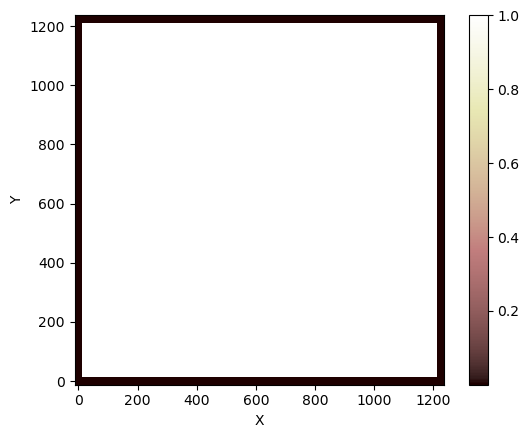

In [28]:
imshow_grid(mg, initialtopo2D)